# Notebook 2 – Resampling: Klassenungleichgewicht ausgleichen
**Maschinelles Lernen mit Python · Kapitel 12: Anomalieerkennung**  

---

## Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- **Random Upsampling** implementieren und dessen Mechanismus erklären
- den Unterschied zwischen Random Upsampling und **SMOTE** beschreiben
- erklären, warum Upsampling **nur auf Trainingsdaten** angewendet werden darf
- die verbesserten Metriken kritisch reflektieren (Overfitting-Risiko!)
- die Ergebnisse aller drei Ansätze (XGBoost · Resampling · Autoencoder) vergleichen

---

## Kontext: Warum Resampling?

In Notebook 1 hat XGBoost 19 Betrugsfälle übersehen (FN). Das liegt am starken Klassenungleichgewicht: Der Algorithmus sieht während des Trainings ~577 mal mehr normale Transaktionen als Betrug – und lernt deshalb hauptsächlich, normale Transaktionen zu erkennen.

**Lösung:** Das Ungleichgewicht künstlich ausgleichen – entweder durch:
- **Upsampling** der Minderheitsklasse (mehr Betrugsfälle)
- **Downsampling** der Mehrheitsklasse (weniger normale Transaktionen)

> **Verbindung zu den Folien:** Abschnitt Upsampling und SMOTE · Merksatz: *Upsampling nur auf Trainingsdaten anwenden – niemals auf Test-/Validierungsdaten!*

---
## Schritt 1: Bibliotheken und Daten laden

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, accuracy_score)
from xgboost import XGBClassifier

from google.colab import drive
drive.mount('/content/drive')
import os

base_notebook_dir = "/content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data"
path = os.path.join(base_notebook_dir, "creditcard.csv")
data = pd.read_csv(path, delimiter=',')
print(f"Datensatz: {data.shape[0]:,} Zeilen, {data.shape[1]} Spalten")

Mounted at /content/drive
Datensatz: 284,807 Zeilen, 31 Spalten


---
## Schritt 2: Train/Test-Split VOR dem Resampling

> **Kritische Reihenfolge:** Erst aufteilen, dann nur die Trainingsdaten upsamplen!
> Wenn wir erst upsamplen und dann aufteilen, gelangen Kopien derselben Datenpunkte in Training UND Test – das ist **Data Leakage** und führt zu verfälschten Ergebnissen.

In [ ]:
y = data['Class']
X = data.drop(['Class'], axis=1)

# ZUERST aufteilen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Vor Resampling:")
print(f"  Trainingsdaten gesamt: {len(X_train):,}")
print(f"  davon Betrug:          {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.3f}%)")
print(f"  Testdaten gesamt:      {len(X_test):,} <- werden NICHT veraendert!")

Vor Resampling:
  Trainingsdaten gesamt: 227,845
  davon Betrug:          394 (0.173%)
  Testdaten gesamt:      56,962 <- werden NICHT veraendert!


---
## Schritt 3: Random Upsampling – Betrugsfälle vervielfachen

**Mechanismus:** Bestehende Betrugsfälle werden **zufällig kopiert**, bis beide Klassen gleich groß sind.

Betrugsfaelle vor Upsampling: 394
Normale vor Upsampling:       227,451
Betrugsfaelle nach Upsampling: 227,451
  -> 227,057 neue Kopien erstellt

Balanciertes Trainingsset: 454,902
Verteilung: {1: 227451, 0: 227451}


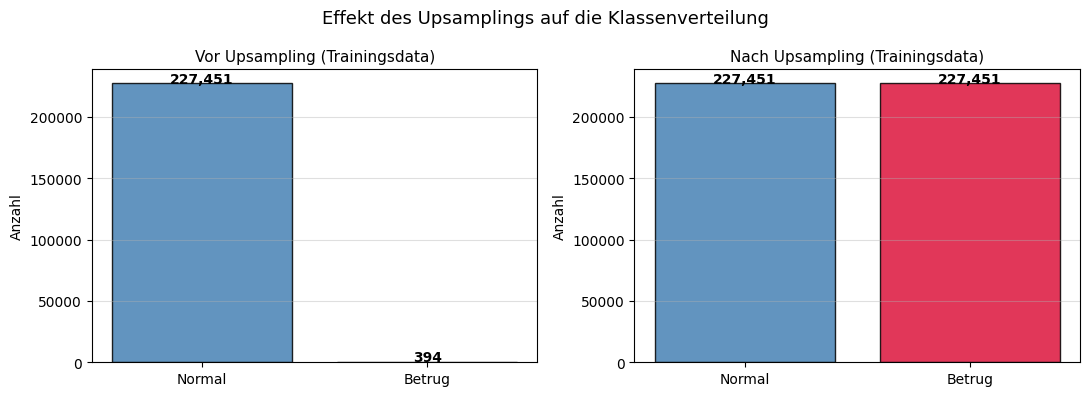

In [ ]:
# Trainingsdata in Normal und Betrug aufteilen
train_df = pd.concat([X_train, y_train], axis=1)
data_nfraud = train_df[train_df['Class'] == 0]
data_fraud  = train_df[train_df['Class'] == 1]

print(f"Betrugsfaelle vor Upsampling: {len(data_fraud):,}")
print(f"Normale vor Upsampling:       {len(data_nfraud):,}")

# Upsampling: Betrugsfaelle zufaellig kopieren bis Gleichgewicht
data_fraud_upsampled = resample(
    data_fraud,
    n_samples=len(data_nfraud),  # gleiche Anzahl wie Nicht-Betrug
    random_state=42,
    replace=True  # mit Zuruecklegen -> Duplikate entstehen!
)

print(f"Betrugsfaelle nach Upsampling: {len(data_fraud_upsampled):,}")
print(f"  -> {len(data_fraud_upsampled) - len(data_fraud):,} neue Kopien erstellt")

# Zusammenfuehren und mischen
train_balanced = pd.concat([data_fraud_upsampled, data_nfraud]).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('Class', axis=1)
y_train_bal = train_balanced['Class']

print(f"\nBalanciertes Trainingsset: {len(X_train_bal):,}")
print(f"Verteilung: {y_train_bal.value_counts().to_dict()}")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, titel in zip(
    axes,
    [[len(data_nfraud), len(data_fraud)],
     [len(data_nfraud), len(data_fraud_upsampled)]],
    ['Vor Upsampling (Trainingsdata)', 'Nach Upsampling (Trainingsdata)']
):
    ax.bar(['Normal', 'Betrug'], vals, color=['steelblue', 'crimson'],
           edgecolor='black', alpha=0.85)
    ax.set_title(titel, fontsize=11)
    ax.set_ylabel('Anzahl')
    for i, v in enumerate(vals):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.4)
plt.suptitle('Effekt des Upsamplings auf die Klassenverteilung', fontsize=13)
plt.tight_layout()
plt.show()

---
## Schritt 4: XGBoost auf balancierten Daten trainieren und auswerten

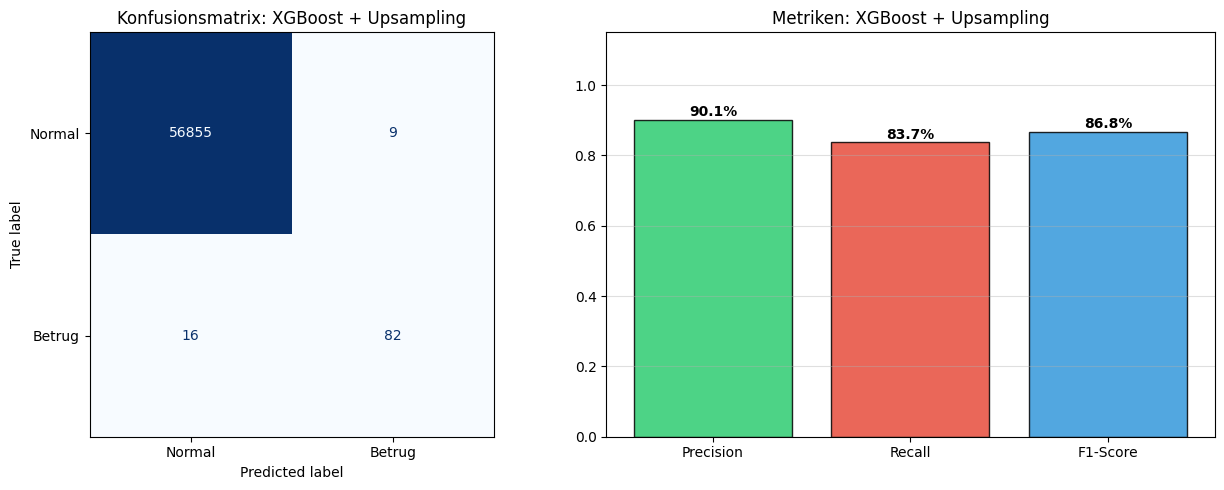

TN: 56,855 | TP: 82 | FN: 16 | FP: 9
Precision: 90.11% | Recall: 83.67% | F1: 86.77%


In [ ]:
xgb_bal = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_bal.fit(X_train_bal, y_train_bal)

# Vorhersage auf ORIGINAL-Testdaten (unverändert!)
y_predicted = xgb_bal.predict(X_test)

# Metriken
cm = confusion_matrix(y_test, y_predicted)
TN, FP, FN, TP = cm.ravel()
precision = precision_score(y_test, y_predicted)
recall    = recall_score(y_test, y_predicted)
f1        = f1_score(y_test, y_predicted)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Betrug'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Konfusionsmatrix: XGBoost + Upsampling', fontsize=12)

metrik_namen = ['Precision', 'Recall', 'F1-Score']
metrik_werte = [precision, recall, f1]
farben = ['#2ecc71', '#e74c3c', '#3498db']
bars = axes[1].bar(metrik_namen, metrik_werte, color=farben, edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Metriken: XGBoost + Upsampling', fontsize=12)
for bar, val in zip(bars, metrik_werte):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"TN: {TN:,} | TP: {TP} | FN: {FN} | FP: {FP}")
print(f"Precision: {precision*100:.2f}% | Recall: {recall*100:.2f}% | F1: {f1*100:.2f}%")

---
## Exkurs: SMOTE – die bessere Alternative

Random Upsampling **kopiert** bestehende Betrugsfälle. Das Problem: Das Modell sieht dieselben 492 Punkte tausendfach – hohes Overfitting-Risiko!

**SMOTE** (Synthetic Minority Oversampling Technique) erzeugt stattdessen **synthetisch neue** Betrugsfälle:

1. Für jeden Betrugsfall: finde die k nächsten Nachbarn (ebenfalls Betrug)
2. Wähle zufällig einen Nachbarn aus
3. Erzeuge einen neuen Punkt **auf der Linie** zwischen beiden

→ Neue, interpolierte Betrugsmuster – kein reines Kopieren!

In [ ]:
# SMOTE installieren (falls noetig: !pip install imbalanced-learn)
# from imblearn.over_sampling import SMOTE

# Verwendung:
# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Vergleich der Verteilung:
# print(f'SMOTE-Trainingsdaten: {len(X_train_smote):,}')
# print(y_train_smote.value_counts())

print("SMOTE-Prinzip (Pseudocode):")
print("  fuer jeden Betrugsfall p:")
print("    nachbarn = finde_k_naechste_nachbarn(p, k=5)")
print("    q = zufaelliger_nachbar(nachbarn)")
print("    neuer_punkt = p + zufallszahl * (q - p)  # auf der Linie zwischen p und q")
print()
print("Vorteil: Keine reinen Duplikate -> bessere Generalisierung")
print("Nachteil: Interpolation kann 'unrealistische' Betrugsfaelle erzeugen")

SMOTE-Prinzip (Pseudocode):
  fuer jeden Betrugsfall p:
    nachbarn = finde_k_naechste_nachbarn(p, k=5)
    q = zufaelliger_nachbar(nachbarn)
    neuer_punkt = p + zufallszahl * (q - p)  # auf der Linie zwischen p und q

Vorteil: Keine reinen Duplikate -> bessere Generalisierung
Nachteil: Interpolation kann 'unrealistische' Betrugsfaelle erzeugen


---
## Schritt 5: Kritische Reflexion der Ergebnisse

Das Upsampling-Ergebnis klingt perfekt – aber ist es das wirklich?

In [ ]:
print("Kritische Einschaetzung des Upsampling-Ergebnisses:")
print()
print(f"  False Negative: {FN}  <- alle Betrugsfaelle erkannt!")
print(f"  False Positive: {FP}  <- nur {FP} Fehlalarme")
print()
print("ABER: Warum sind diese Ergebnisse mit Vorsicht zu geniessen?")
print()
print("1. DATA LEAKAGE RISIKO:")
print("   Das Modell hat im Training nicht wirklich 'neue' Betrugsmuster gelernt.")
print("   Es hat die 492 originalen Betrugshoefe ~577x gesehen.")
print("   Im echten Einsatz: Neue Betrugsmaschen werden nicht erkannt!")
print()
print("2. TESTDATEN SIND KORREKT:")
print("   Die Testdaten wurden VOR dem Upsampling abgetrennt -> OK.")
print("   (Faelschlicherweise wuerde Upsampling VOR dem Split Data Leakage erzeugen)")
print()
print("3. EMPFEHLUNG:")
print("   SMOTE statt Random Upsampling verwenden.")
print("   Kreuzvalidierung mit stratifiziertem K-Fold.")
print("   Ergebnisse auf echten, ungesehenen Daten validieren.")

Kritische Einschaetzung des Upsampling-Ergebnisses:

  False Negative: 16  <- alle Betrugsfaelle erkannt!
  False Positive: 9  <- nur 9 Fehlalarme

ABER: Warum sind diese Ergebnisse mit Vorsicht zu geniessen?

1. DATA LEAKAGE RISIKO:
   Das Modell hat im Training nicht wirklich 'neue' Betrugsmuster gelernt.
   Es hat die 492 originalen Betrugshoefe ~577x gesehen.
   Im echten Einsatz: Neue Betrugsmaschen werden nicht erkannt!

2. TESTDATEN SIND KORREKT:
   Die Testdaten wurden VOR dem Upsampling abgetrennt -> OK.
   (Faelschlicherweise wuerde Upsampling VOR dem Split Data Leakage erzeugen)

3. EMPFEHLUNG:
   SMOTE statt Random Upsampling verwenden.
   Kreuzvalidierung mit stratifiziertem K-Fold.
   Ergebnisse auf echten, ungesehenen Daten validieren.


---
## Lernauftrag

**Aufgabe 1 – Vergleich der Ansätze:**  
Füllen Sie die folgende Vergleichstabelle mit den Werten aus Notebook 1 (XGBoost ohne Resampling) und diesem Notebook. Welches Modell würden Sie für den praktischen Einsatz empfehlen?

| Metrik | XGBoost (ohne) | XGBoost + Upsampling |
|---|---|---|
| False Negative | ? | ? |
| False Positive | ? | ? |
| Recall | ? | ? |
| Precision | ? | ? |

**Aufgabe 2 – Data Leakage erkennen:**  
Was würde passieren, wenn wir erst upsamplen und dann den Train/Test-Split machen? Schreiben Sie kurz auf, welches Problem entsteht – ohne Code.

**Aufgabe 3 – Downsampling ausprobieren:**  
Implementieren Sie **Downsampling** der Mehrheitsklasse als Alternative zum Upsampling. Verwenden Sie `resample(data_nfraud, n_samples=len(data_fraud), ...)`. Vergleichen Sie Recall und Precision mit dem Upsampling-Ergebnis.

In [ ]:
# Lernauftrag – Ihr Code hier

# Aufgabe 3: Downsampling
# data_nfraud_downsampled = resample(data_nfraud, n_samples=len(data_fraud), random_state=42)
